# Monte Carlo: LPED half-window `d` vs. TRGB error

Small `d` follows the edge but counts few stars (noisy response); large `d` is stable but smears the
edge. What does that trade-off cost, and can the peak diagnostics flag a bad detection without
knowing the truth?

Every realization is analysed with **all** `d` values, so the comparison is paired. Failed detections
are kept as rows with `success = False` and the exception message.


In [1]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize_scalar

from tqdm.auto import tqdm

from trgb_lib import *

print("ok")

ok


In [3]:
# ============================================================
# Simulation parameters
# ============================================================

m_trgb = 10.0

alpha_rgb = 0.30
rgb_range = 3.0
N_rgb_1mag = 200

alpha_agb = 0.20
agb_range = 2.0
N_agb_1mag = round(N_rgb_1mag/5)

photometric_error = 0.03



In [17]:
N_realizations = 1000

d_values = np.array([0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,])

step = 0.01

In [18]:
# ============================================================
# Independent random-number streams
# ============================================================

master_seed = random_seed()

master_sequence = np.random.SeedSequence(master_seed)
realization_sequences = master_sequence.spawn(N_realizations)

# ============================================================
# Monte Carlo simulation
# ============================================================

results = []

for realization, realization_sequence in enumerate(tqdm(realization_sequences, desc="Monte Carlo")):    

    # Independent streams for RGB, AGB and photometric noise
    rgb_sequence, agb_sequence, phot_sequence = (realization_sequence.spawn(3))

    seed_rgb = int(rgb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_agb = int(agb_sequence.generate_state(1, dtype=np.uint32)[0])
    seed_phot = int(phot_sequence.generate_state(1, dtype=np.uint32)[0])

    # --------------------------------------------------------
    # Generate one luminosity function
    # --------------------------------------------------------

    m_rgb = rgb_lf(m_trgb=m_trgb,alpha=alpha_rgb,m_range=rgb_range,N_1mag=N_rgb_1mag,seed=seed_rgb,)
    m_agb = agb_powerlaw_lf(m_trgb=m_trgb,alpha=alpha_agb,m_range=agb_range,N_agb_1mag=N_agb_1mag,seed=seed_agb,)
    m = np.concatenate((m_rgb,m_agb,))
    m = add_photometric_errors(m,errors=photometric_error,seed=seed_phot,)
    m = np.sort(m)

    # --------------------------------------------------------
    # Apply all d values to the same luminosity function
    # --------------------------------------------------------

    for d in d_values:

        try:

            alpha_mle, alpha_err, res = fit_alpha_mle(m,m1=m_trgb + 0.5,m2=m_trgb + 2.0,)
            x_filter, response, counts_bright, counts_faint = local_poisson_filter(m,d=d,alpha=alpha_mle,step=step,sigma=0.0,method="score",)
            trgb_detected, diagnostics = detect_local_peak(x_filter,response,d=d,initial=m_trgb,search_range=0.5,competitor_fraction=0.5)

            trgb_error = trgb_detected - m_trgb

            results.append({
                "realization": realization,
                "d": d,
                
                "seed_rgb": seed_rgb,
                "seed_agb": seed_agb,
                "seed_phot": seed_phot,

                "trgb_true": m_trgb,
                "trgb_detected": trgb_detected,
                "trgb_error": trgb_error,
                "absolute_error": abs(trgb_error),

                "peak_height":diagnostics.get("peak_height",np.nan,),
                "peak_prominence":diagnostics.get("peak_prominence",np.nan,),
                "peak_width":diagnostics.get("peak_width_half_prominence",np.nan,),
                "peak_flatness":diagnostics.get("peak_flatness",np.nan,),
                "area_with_main":diagnostics.get("area_with_main",np.nan,),
                "area_without_main":diagnostics.get("area_without_main",np.nan,),
                "outside_area_fraction":diagnostics.get("outside_area_fraction",np.nan,),

                "success": True,
                "error_message": "",
            })

        except (
            ValueError,
            RuntimeError,
            IndexError,
            ZeroDivisionError,
        ) as error:

            results.append({
                "realization": realization,
                "d": d,

                "seed_rgb": seed_rgb,
                "seed_agb": seed_agb,
                "seed_phot": seed_phot,

                "trgb_true": m_trgb,
                "trgb_detected": np.nan,
                "trgb_error": np.nan,
                "absolute_error": np.nan,

                "peak_height": np.nan,
                "peak_prominence": np.nan,
                "peak_width": np.nan,
                "peak_flatness": np.nan,

                "area_with_main": np.nan,
                "area_without_main": np.nan,
                "outside_area_fraction": np.nan,

                "success": False,
                "error_message": str(error),
            })



Monte Carlo:   0%|          | 0/1000 [00:00<?, ?it/s]

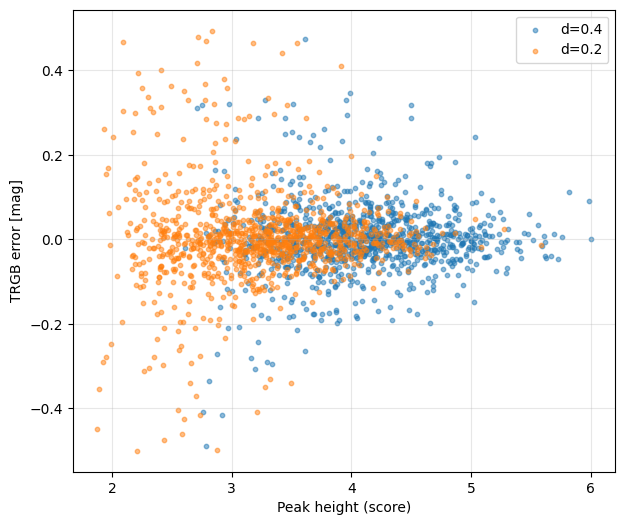

In [19]:
d1 = 0.4
d2 = 0.2

y1 = []
error1 = []

y2 = []
error2 = []

for r in results:

    if not r["success"]:
        continue

    if r["d"] == d1:
        y1.append(r["peak_height"])
        error1.append(r["trgb_error"])

    elif r["d"] == d2:
        y2.append(r["peak_height"])
        error2.append(r["trgb_error"])


plt.figure(figsize=(7,6))

plt.scatter(y1, error1, s=10, alpha=0.5, label=f"d={d1}")
plt.scatter(y2, error2, s=10, alpha=0.5, label=f"d={d2}")

plt.xlabel("Peak height (score)")
plt.ylabel("TRGB error [mag]")

plt.grid(alpha=0.3)
plt.legend()

plt.show()        